<a href="https://colab.research.google.com/github/Mousamjha/pytorch_deep_learning/blob/main/image_classification_multi_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q kagglehub

In [3]:
import kagglehub
import os

path = kagglehub.dataset_download("andrewmvd/animal-faces")

print("Dataset path:", path)
print(os.listdir(path))

100%|██████████| 696M/696M [00:35<00:00, 20.3MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/andrewmvd/animal-faces/versions/1
['afhq']


In [4]:
import torch
from torchsummary import summary
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
import os
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"

['val', 'train']
val
train


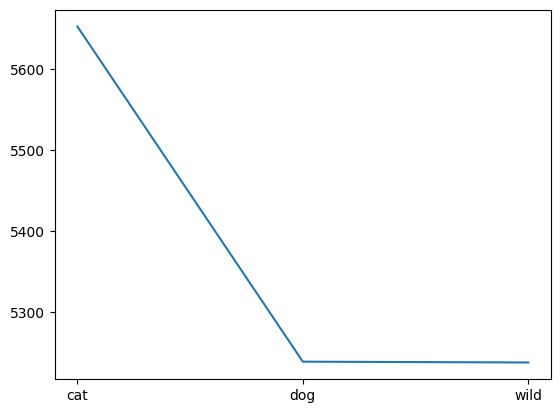

In [5]:
image_paths = []
labels = []
paths = path+"/afhq/"
print(os.listdir(paths))
for i in os.listdir(paths):
    print(i)
    for label in os.listdir(paths+"/"+i):
        for image in os.listdir(paths+"/"+i+"/"+label):
            image_paths.append(paths+i+"/"+label+"/"+image)
            labels.append(label)

data_df = pd.DataFrame(zip(image_paths, labels), columns=["image_paths", "labels"])
plt.plot(data_df['labels'].value_counts())

In [6]:
data_df.head()

,image_paths,labels
0,/root/.cache/kagglehub/datasets/andrewmvd/anim...,cat
1,/root/.cache/kagglehub/datasets/andrewmvd/anim...,cat
2,/root/.cache/kagglehub/datasets/andrewmvd/anim...,cat
3,/root/.cache/kagglehub/datasets/andrewmvd/anim...,cat
4,/root/.cache/kagglehub/datasets/andrewmvd/anim...,cat


In [7]:
train_df, val_df = train_test_split(data_df, test_size=0.3, random_state=42, stratify=data_df['labels'])
test_df, val_df = train_test_split(val_df, test_size=0.5, stratify=val_df['labels'])

In [8]:
print(f"Train Shape: {train_df.shape}")
print(f"Test Shape: {test_df.shape}")
print(f"Val Shape: {val_df.shape}")
print(f"Train label counts: {train_df['labels'].value_counts()}")
print(f"Test label counts: {test_df['labels'].value_counts()}")
print(f"Val label counts: {val_df['labels'].value_counts()}")

Train Shape: (11291, 2)
Test Shape: (2419, 2)
Val Shape: (2420, 2)
Train label counts: labels
cat     3957
dog     3667
wild    3667
Name: count, dtype: int64
Test label counts: labels
cat     848
dog     786
wild    785
Name: count, dtype: int64
Val label counts: labels
cat     848
dog     786
wild    786
Name: count, dtype: int64


In [9]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df['labels'])

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])


In [10]:
class CustomImageDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image).to(device)

        return image, label


In [11]:
train_dataset = CustomImageDataset(train_df, transform=transform)
val_dataset = CustomImageDataset(val_df, transform=transform)
test_dataset = CustomImageDataset(test_df, transform=transform)


In [12]:
train_dataset.__len__()

11291

In [13]:
train_dataset.__getitem__(0)

(tensor([[[0.4824, 0.4745, 0.4706,  ..., 0.7373, 0.7412, 0.7294],
          [0.4784, 0.4706, 0.4667,  ..., 0.7373, 0.7373, 0.7333],
          [0.4627, 0.4549, 0.4549,  ..., 0.7294, 0.7333, 0.7333],
          ...,
          [0.5098, 0.4980, 0.4824,  ..., 0.8863, 0.8275, 0.8196],
          [0.5176, 0.5059, 0.4941,  ..., 0.8588, 0.8863, 0.8667],
          [0.5216, 0.5098, 0.4980,  ..., 0.7961, 0.8549, 0.8902]],
 
         [[0.3725, 0.3647, 0.3608,  ..., 0.5608, 0.5647, 0.5529],
          [0.3686, 0.3608, 0.3569,  ..., 0.5608, 0.5608, 0.5569],
          [0.3569, 0.3490, 0.3490,  ..., 0.5529, 0.5569, 0.5569],
          ...,
          [0.5216, 0.5098, 0.4941,  ..., 0.8902, 0.8314, 0.8235],
          [0.5294, 0.5176, 0.5059,  ..., 0.8627, 0.8902, 0.8706],
          [0.5333, 0.5216, 0.5098,  ..., 0.8000, 0.8588, 0.8941]],
 
         [[0.3255, 0.3176, 0.3137,  ..., 0.4000, 0.4039, 0.3922],
          [0.3176, 0.3098, 0.3059,  ..., 0.4000, 0.4000, 0.3961],
          [0.2902, 0.2824, 0.2824,  ...,

In [14]:
label_encoder.inverse_transform([1]).item()

'dog'

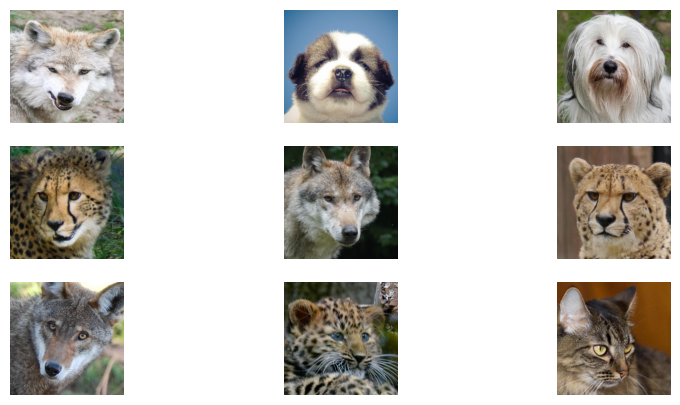

In [15]:
n_row = 3
n_col = 3
f, axarr = plt.subplots(n_row, n_col, figsize = (10, 5))
for row in range(n_row):
    for col in range(n_col):
        image = Image.open(data_df.sample(n = 1)["image_paths"].iloc[0]).convert("RGB")
        axarr[row, col].imshow(image)
        axarr[row, col].axis('off')
plt.show()

In [16]:
LR = 1e-4
EPOCHS = 15
BATCH_SIZE = 16

In [17]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [18]:
class Net(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()

        self.relu = nn.ReLU()

        self.linear = nn.Linear(in_features=(128 * 16 *16), out_features=128)

        self.output = nn.Linear(128, len(data_df['labels'].unique()))

    def forward(self, x):
        x = self.conv1(x) #(32, 128 ,128)
        x = self.max_pool(x) #(32, 64, 64)
        x = self.relu(x)

        x = self.conv2(x) #(64, 64, 64)
        x = self.max_pool(x) #(64, 32, 32)
        x = self.relu(x)

        x = self.conv3(x) #(128, 32, 32)
        x = self.max_pool(x) #(128, 16, 16)
        x = self.relu(x)

        x = self.flatten(x)
        x = self.linear(x)
        x = self.relu(x)
        x = self.output(x)
        return x

In [19]:
model = Net().to(device)

In [20]:
summary(model, (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
             ReLU-12                  [-1, 128]               0
           Linear-13                    [-1, 3]             387
Total params: 4,288,067
Trainable param

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)

In [ ]:
total_loss_train_plot = []
total_loss_val_plot = []
total_acc_train_plot = []
total_acc_val_plot = []

for epoch in range(EPOCHS):
    train_loss = 0
    train_acc = 0
    val_loss = 0
    val_acc = 0

    for inputs, labels in train_loader:
        # inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
        train_acc += acc
        train_loss += loss.item()
        optimizer.step()

    with torch.no_grad():
        for inputs, labels in val_loader:
            # inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
            val_loss += loss.item()
            val_acc += acc

    total_loss_train_plot.append(round(train_loss / 1000, 4))

    total_loss_val_plot.append(round(val_loss / 1000, 4))

    total_acc_train_plot.append(round(train_acc/train_dataset.__len__() *100, 4))

    total_acc_val_plot.append(round(val_acc/val_dataset.__len__()*100, 4))

    print(f"Epoch: {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {round(train_loss / 1000, 4)}")
    print(f"Val Loss: {round(val_loss / 1000, 4)}")
    print(f"Train Acc: {round(train_acc/train_dataset.__len__()*100, 4)}")
    print(f"Val Acc: {round((val_acc/val_dataset.__len__()) *100, 4)}")
    print("="*35)